In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,...,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,...,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,...,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,...,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,...,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               4280 non-null   str    
 1   order_date             4280 non-null   str    
 2   customer_id            4280 non-null   str    
 3   customer_name          4280 non-null   str    
 4   age                    4150 non-null   float64
 5   gender                 4280 non-null   str    
 6   region                 4280 non-null   str    
 7   city                   4280 non-null   str    
 8   product_category       4280 non-null   str    
 9   product_name           4280 non-null   str    
 10  quantity               4170 non-null   float64
 11  unit_price             4280 non-null   float64
 12  discount_pct           4143 non-null   float64
 13  sales_amount           4280 non-null   float64
 14  profit                 4280 non-null   float64
 15  shipping_cost  

In [3]:
df[df['order_id'].isnull()].shape

(30, 21)

In [4]:
df[df['order_id'].isnull()].head()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df = df.dropna(subset=['order_id'])
df.shape

(4280, 21)

In [6]:
# age: fill with median (age doesn't skew easily from one weird value)
df['age'] = df['age'].fillna(df['age'].median())

# quantity: fill with median (whole number quantities, median is safer than mean)
df['quantity'] = df['quantity'].fillna(df['quantity'].median())

# discount_pct: missing likely means no discount was recorded
df['discount_pct'] = df['discount_pct'].fillna(0)

# customer_satisfaction: missing likely means no survey response — keep as NaN 
# (filling this with a fake number would distort satisfaction analysis, so we leave it)

# days_to_ship: fill with median shipping time
df['days_to_ship'] = df['days_to_ship'].fillna(df['days_to_ship'].median())

In [8]:
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=False)

In [9]:
df['order_date'].min(), df['order_date'].max()

(Timestamp('2020-01-01 00:00:00'), Timestamp('2024-12-30 00:00:00'))

In [10]:
df.isnull().sum()

order_id                   0
order_date                 0
customer_id                0
customer_name              0
age                        0
gender                     0
region                     0
city                       0
product_category           0
product_name               0
quantity                   0
unit_price                 0
discount_pct               0
sales_amount               0
profit                     0
shipping_cost              0
payment_method             0
customer_satisfaction    348
return_flag                0
order_status               0
days_to_ship               0
dtype: int64

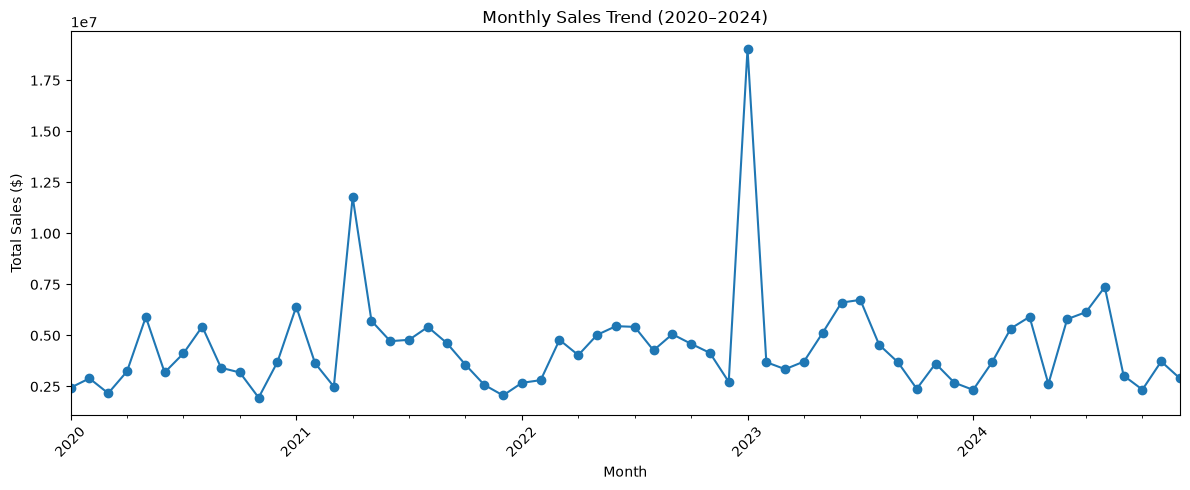

In [11]:
# Create a month-year column for grouping
df['order_month'] = df['order_date'].dt.to_period('M')

monthly_sales = df.groupby('order_month')['sales_amount'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend (2020–2024)')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

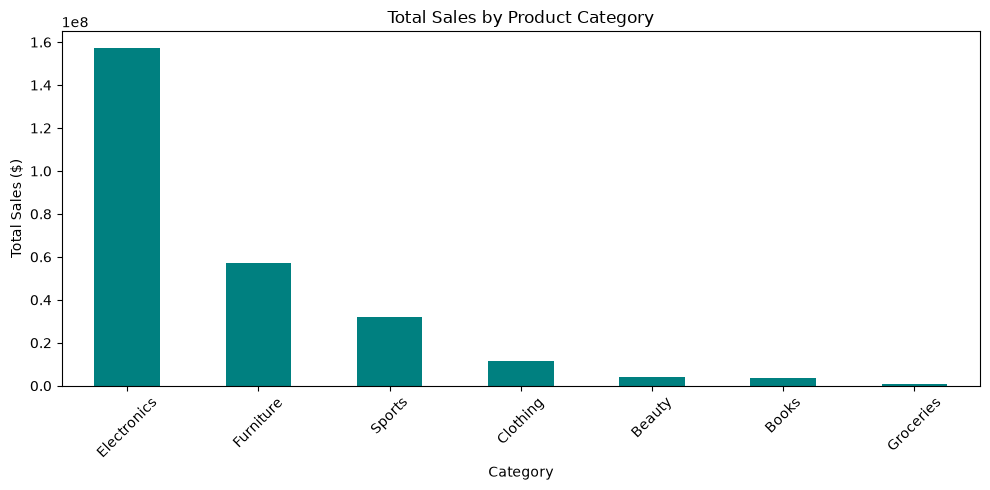

In [12]:
category_sales = df.groupby('product_category')['sales_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
category_sales.plot(kind='bar', color='teal')
plt.title('Total Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
monthly_sales.sort_values(ascending=False).head(3)

order_month
2023-01    19042166.36
2021-04    11781947.77
2024-08     7373900.60
Freq: M, Name: sales_amount, dtype: float64

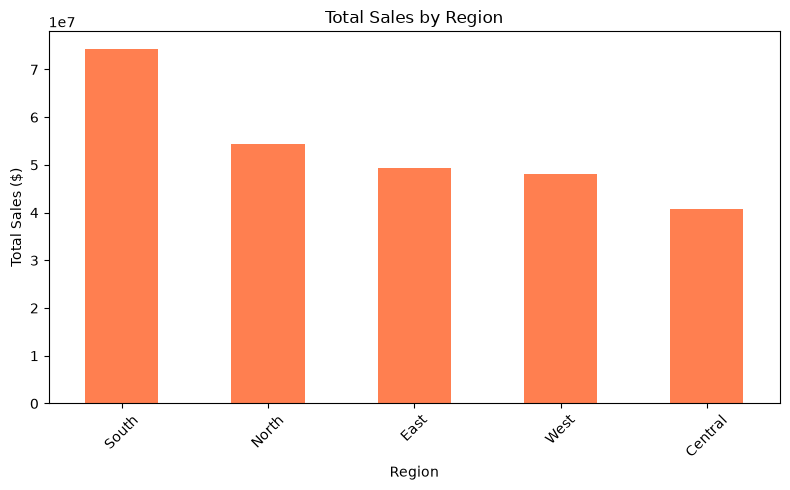

In [14]:
region_sales = df.groupby('region')['sales_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar', color='coral')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

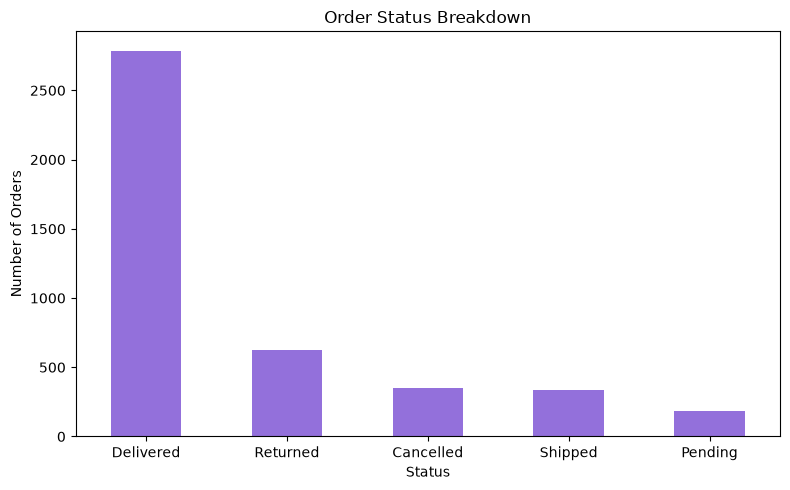

In [19]:
df['order_status'] = df['order_status'].str.lower().str.capitalize()

# Re-plot
plt.figure(figsize=(8,5))
df['order_status'].value_counts().plot(kind='bar', color='mediumpurple')
plt.title('Order Status Breakdown')
plt.xlabel('Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

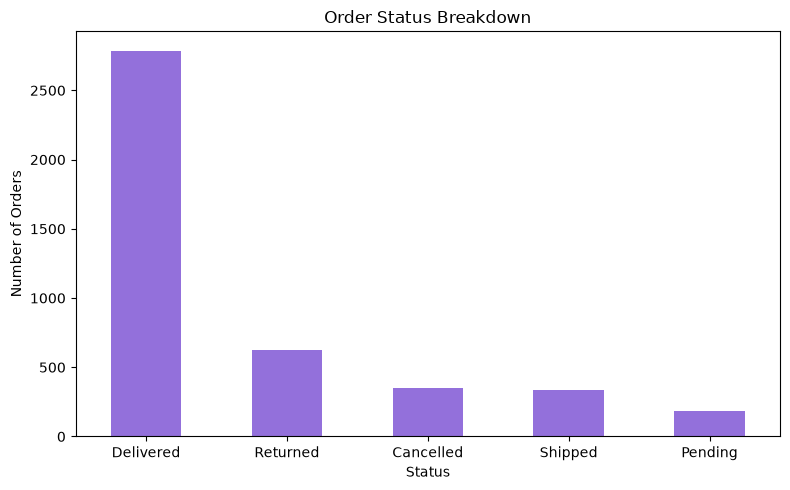

In [20]:
df['order_status'] = df['order_status'].str.lower().str.capitalize()

# Re-plot
plt.figure(figsize=(8,5))
df['order_status'].value_counts().plot(kind='bar', color='mediumpurple')
plt.title('Order Status Breakdown')
plt.xlabel('Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
return_rate = df['return_flag'].mean() * 100
print(f"Return rate: {return_rate:.2f}%")

Return rate: 14.56%


In [21]:
df.groupby('product_category')['return_flag'].mean().sort_values(ascending=False)

product_category
Electronics     0.15935
Groceries      0.157895
Sports           0.1536
Clothing       0.137984
Beauty         0.137255
Books          0.136126
Furniture      0.135506
Name: return_flag, dtype: object

## Key Insights

1. **Category concentration risk**: Electronics dominates revenue (~$157M), 
   more than 2.7x Furniture (the next highest). The business is heavily 
   reliant on a single category.

2. **Sales spikes**: Two anomalous months stand out — January 2023 (~$19M) 
   and April 2021 (~$11.8M) — far above the typical $2.5-7M monthly range. 
   Worth investigating further (promotions, bulk orders, or data anomalies).

3. **Regional distribution is balanced**: Unlike category sales, regional 
   sales are relatively even (South leads at ~$74M, Central lowest at ~$41M) 
   — no single region dominates the way Electronics does among categories.

4. **Discounts don't move sales**: Correlation between discount_pct and 
   sales_amount/profit is close to zero (-0.05), suggesting current 
   discounting strategy isn't effectively driving purchase behavior.

5. **Profit tracks sales closely**: A 0.95 correlation between sales_amount 
   and profit indicates costs scale predictably with revenue.

6. **Return rate is 14.56% overall**, and fairly consistent across all 
   product categories (13.5%-16%) — suggesting returns are a systemic issue 
   (e.g. shipping, expectations, product descriptions) rather than tied to 
   any specific category.

7. **Data quality note**: `order_status` values had inconsistent 
   capitalization (e.g. "Delivered" vs "delivered"), which was normalized 
   before analysis.